In [ ]:
#conversacion con gemini
#https://gemini.google.com/app/426bc4c5fd71d1c3

import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [2]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [6]:
# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout.primitives.mimcap import mimcap, mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import align_comp_to_port, evaluate_bbox

In [7]:


lif_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation(),
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

# Base parameters for PMOS and NMOS
nmos_kwargs = {
    "with_tie": False,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

pmos_kwargs = {
    "with_tie": False,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

In [8]:
pdk = lif_config["pdk"]
lif = Component(name="lif")
# --- PMOS Transistors ---
# M6: Charge source (W=0.22u, L=17u)
m6 = pmos(pdk, width=0.5, length=17.0, **pmos_kwargs)
# M1: First stage inv PMOS (W=0.22u, L=0.28u)
m1 = pmos(pdk, width=0.5, length=0.28, **pmos_kwargs)
# M3: Second stage inv PMOS (W=0.22u, L=0.28u)
m3 = pmos(pdk, width=0.5, length=0.28, **pmos_kwargs)
# M7: Output stage inv PMOS (W=0.22u, L=0.28u)
m7 = pmos(pdk, width=0.5, length=0.28, **pmos_kwargs)

# --- NMOS Transistors ---
# M2: First stage inv NMOS (W=0.22u, L=0.28u)
m2 = nmos(pdk, width=0.5, length=0.28, **nmos_kwargs)
# M4: Second stage inv NMOS (W=0.22u, L=0.28u)
m4 = nmos(pdk, width=0.5, length=0.28, **nmos_kwargs)
# M8: Output stage inv NMOS (W=0.22u, L=0.28u)
m8 = nmos(pdk, width=0.5, length=0.28, **nmos_kwargs)
# M5: Reset NMOS (W=1.25u, L=50u)
m5 = nmos(pdk, width=1.25, length=50.0, **nmos_kwargs)

# --- Membrane Capacitor ---
# C1: MIM Cap (~150 fF requiring roughly 10u x 15u area)
c1 = mimcap(pdk, size=(10.0, 15.0))

# ==============================================================================
# 2. Add References & Perform Relative Placement
# ==============================================================================
# Add PMOS devices to cell
m6_ref = lif << m6
m1_ref = lif << m1
m3_ref = lif << m3
m7_ref = lif << m7

# Add NMOS devices to cell
m2_ref = lif << m2
m4_ref = lif << m4
m8_ref = lif << m8
m5_ref = lif << m5

# Add Capacitor
c1_ref = lif << c1
# Placement Grid Offsets (in microns)
PITCH_X = 12.0
N_P_GAP_Y = 15.0

# Align PMOS Row (Top Block)
m6_ref.move((0, N_P_GAP_Y))
m1_ref.move((PITCH_X, N_P_GAP_Y))
m3_ref.move((2 * PITCH_X, N_P_GAP_Y))
m7_ref.move((3 * PITCH_X, N_P_GAP_Y))

# Align NMOS Row (Bottom Block)
m5_ref.move((0, 0))
m2_ref.move((PITCH_X, 0))
m4_ref.move((2 * PITCH_X, 0))
m8_ref.move((3 * PITCH_X, 0))

# Place Capacitor array adjacent on the right
c1_ref.move((4 * PITCH_X, N_P_GAP_Y / 2))


ComponentReference (parent Component "Unnamed_d15f0245", ports ['bottom_met_W', 'bottom_met_N', 'bottom_met_E', 'bottom_met_S', 'array_row0_col0_bottom_layer_W', 'array_row0_col0_bottom_via_W', 'array_row0_col0_bottom_met_W', 'array_row0_col0_top_met_W', 'array_row0_col1_bottom_layer_W', 'array_row0_col1_bottom_via_W', 'array_row0_col1_bottom_met_W', 'array_row0_col1_top_met_W', 'array_row0_col2_bottom_layer_W', 'array_row0_col2_bottom_via_W', 'array_row0_col2_bottom_met_W', 'array_row0_col2_top_met_W', 'array_row0_col3_bottom_layer_W', 'array_row0_col3_bottom_via_W', 'array_row0_col3_bottom_met_W', 'array_row0_col3_top_met_W', 'array_row0_col4_bottom_layer_W', 'array_row0_col4_bottom_via_W', 'array_row0_col4_bottom_met_W', 'array_row0_col4_top_met_W', 'array_row0_col5_bottom_layer_W', 'array_row0_col5_bottom_via_W', 'array_row0_col5_bottom_met_W', 'array_row0_col5_top_met_W', 'array_row0_col6_bottom_layer_W', 'array_row0_col6_bottom_via_W', 'array_row0_col6_bottom_met_W', 'array_row0_

In [16]:
# ==============================================================================
# 3. Routing & Connections
# ==============================================================================

# --- Node: spike_neg (M1 Gate, M2 Gate -> M1/M2 Drains -> M3/M4 Gates -> M7/M8 Gates) ---
# Gate alignment: M1 & M2
r_m1_m2_gate = lif << straight_route(pdk, m1_ref.ports["gate_W"], m2_ref.ports["gate_W"])
# Drain coupling: M1 & M2
r_m1_m2_drain = lif << straight_route(pdk, m1_ref.ports["multiplier_0_drain_E"], m2_ref.ports["multiplier_0_drain_E"])

# Drive spike_neg from Inverter 1 to Inverter 2 gate
r_inv1_inv2 = lif << c_route(pdk, m1_ref.ports["multiplier_0_drain_E"], m3_ref.ports["gate_E"])
# Drive spike_neg to Output Inverter (M7/M8) gate
r_inv2_inv3 = lif << c_route(pdk, m3_ref.ports["gate_E"], m7_ref.ports["gate_E"])

# --- Node: spike_reset (M3/M4 Drains -> M5 Gate) ---
# Gate alignment: M3 & M4
r_m3_m4_gate = lif << straight_route(pdk, m3_ref.ports["gate_W"], m4_ref.ports["gate_W"])
# Drain coupling: M3 & M4
r_m3_m4_drain = lif << straight_route(pdk, m3_ref.ports["multiplier_0_drain_E"], m4_ref.ports["multiplier_0_drain_E"])
# Connection from M3/M4 drain to M5 (reset FET gate)
r_reset = lif << c_route(pdk, m4_ref.ports["multiplier_0_drain_E"], m5_ref.ports["gate_E"])

# --- Node: integration (M6 Drain -> C1 top plate -> M1/M2 Gate -> M5 Drain) ---
# Charge path from M6 drain to M1/M2 gate
r_integ1 = lif << straight_route(pdk, m6_ref.ports["multiplier_0_drain_E"], m1_ref.ports["gate_W"])
# Discharge path to M5 drain
r_integ2 = lif << straight_route(pdk, m5_ref.ports["multiplier_0_drain_E"], m1_ref.ports["gate_W"])
# Membrane storage path to Capacitor C1
r_integ_cap = lif << c_route(pdk, m6_ref.ports["multiplier_0_drain_E"], c1_ref.ports["top_met_E"])

# --- Node: spike (M7 & M8 Drains) ---
# Gate alignment: M7 & M8
r_m7_m8_gate = lif << straight_route(pdk, m7_ref.ports["gate_W"], m8_ref.ports["gate_W"])
# Output Drain coupling
r_spike = lif << straight_route(pdk, m7_ref.ports["multiplier_0_drain_E"], m8_ref.ports["multiplier_0_drain_E"])



In [17]:
# ==============================================================================
# 4. Port Exporting for Top-Level Connectivity
# ==============================================================================
lif.add_port("Vin", port=m6_ref.ports["gate_W"])
lif.add_port("spike", port=m7_ref.ports["multiplier_0_drain_E"])
lif.add_port("spike_neg", port=m1_ref.ports["multiplier_0_drain_E"])
lif.add_port("Vdd", port=m6_ref.ports["multiplier_0_source_E"])
lif.add_port("Vss", port=m5_ref.ports["multiplier_0_source_E"])



{'name': 'Vss', 'width': 0.5, 'center': [25.53, 1.025], 'orientation': 0.0, 'layer': [36, 0], 'port_type': 'electrical'}

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 9 in 'lif$1'
  gdspath = component.write_gds(
2026-07-30 22:33:46.510 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "reload", "file": "/tmp/gdsfactory/lif$1.gds"}


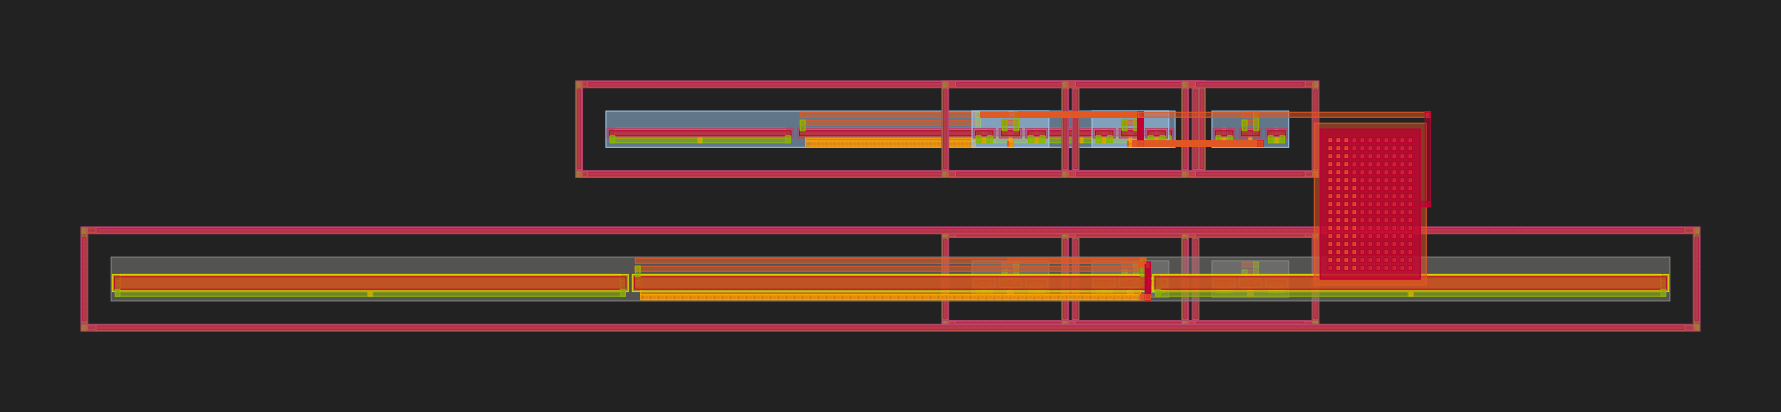

In [18]:
lif.show()
display_component(lif, scale = 1,path=".")

In [ ]:
# Save GDS output
output_path = "./lif_neurona.gds"
lif.write_gds(output_path)
print(f"Layout written successfully to {output_path}")

In [ ]:
#This is the spice to be translated
# .subckt neurona Vdd Vss Vin spike spike_neg
# *.PININFO Vdd:B Vss:B Vin:I spike:O spike_neg:O
# M1 spike_neg integration Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1
# M2 spike_neg integration Vss Vss nfet_03v3 L=0.28u W=0.22u nf=1
# M3 spike/reset spike_neg Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1
# M4 spike/reset spike_neg Vss Vss nfet_03v3 L=0.28u W=0.22u nf=1
# M7 spike spike_neg Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1
# M8 spike spike_neg GND GND nfet_03v3 L=0.28u W=0.22u nf=1
# M5 integration spike/reset Vss Vss nfet_03v3 L=50u W=1.25u nf=1
# C1 integration Vss 150f
# M6 integration Vin Vdd Vdd pfet_03v3 L=17u W=0.22u nf=1
# .ends
# .GLOBAL GND
